# Clinical analysis: MS baseline scans

This notebook investigates whether brain age gap (BAG) measures are associated with clinical variables at baseline in the MS cohort.

The analyses are performed for two model variants:
- the unsmoothed model
- the smoothed model 

The clinical variables investigated here include:
- EDSS at baseline
- fatigue at baseline
- disease duration
- symptom duration

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu
from scipy.stats import pearsonr, spearmanr

In [2]:
# Define paths
project_path = Path("/Users/anneaasengen/MS_project")
pred_csv = project_path / "df_unsmooth_with_res_adj_BAG.csv" # baseline predictions from unsmoothed model
smooth_pred_csv = project_path / "df_smooth_with_res_adj_BAG.csv" # baseline predictions from smoothed model
fatigue_csv = project_path / "Metadata_OFAMS" / "fatigue.csv" # fatigue information

In [3]:
df_unsmooth = pd.read_csv(pred_csv) # predictions from the unsmoothed model
df_smooth = pd.read_csv(smooth_pred_csv) # predictions from the smoothed model
df_fatigue = pd.read_csv(fatigue_csv) # fatigue information

In [4]:
df_unsmooth.head()

,image_path,participant_id,sex,age_BL,EDSS_BL,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group,BAG_residual,disease_duration,symptom_duration,BAG_adj
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,101,F,35.0,1.5,33.492504,-1.507496,33.919716,-1.080284,mild,-12.284878,0,2,-12.475490
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,103,M,24.0,2.5,40.867573,16.867573,41.207672,17.207672,mild,-2.254982,1,2,-3.350060
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,104,F,48.0,1.5,40.905470,-7.094528,41.245125,-6.754875,mild,-8.009435,0,18,-7.335937
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1101,F,46.0,2.0,44.873960,-1.126041,45.166737,-0.833263,mild,-3.558252,1,1,-3.201111
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1102,F,39.0,1.5,48.496895,9.496895,48.746880,9.746880,mild,1.754120,2,2,1.946152


In [5]:
df_smooth.head()

,image_path,participant_id,sex,age_BL,EDSS_BL,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group,BAG_residual,disease_duration,symptom_duration,BAG_adj
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,101,F,35.0,1.5,32.195694,-2.804306,32.905727,-2.094273,mild,-7.430194,0,2,-8.046251
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,103,M,24.0,2.5,36.474022,12.474022,37.120200,13.120201,mild,-1.413909,1,2,-1.526618
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,104,F,48.0,1.5,35.260303,-12.739697,35.924600,-12.075401,mild,-6.419534,0,18,-5.266438
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1101,F,46.0,2.0,36.009117,-9.990883,36.662235,-9.337765,mild,-5.354728,1,1,-6.315050
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1102,F,39.0,1.5,46.991196,7.991196,47.480396,8.480396,mild,6.733323,2,2,5.987143


In [6]:
# Modifying the fatigue dataframe
df_fatigue = df_fatigue.drop(columns=["Unnamed: 0"]) # Remove column "Unnamed: 0"
df_fatigue = df_fatigue.rename(columns={"eid": "participant_id"}) # Change column name
df_fatigue["session"] = df_fatigue["session"] - 1 # Modifying the values so it corresponds to month 0 (baseline), 6, 12, 24

In [7]:
df_fatigue.head()

,participant_id,session,fatigue
0,101,0,6.888889
1,101,6,6.777778
2,101,12,6.888889
3,101,24,6.444444
4,103,0,2.000000


## EDSS analysis

### Plot: EDSS vs residual BAG

This section investigates whether residual BAG is associated with EDSS at baseline.

Residual BAG is used as an age-residualized measure of brain age gap, meaning that the linear association between BAG and chronological age has been removed.

In [8]:
def plot_bag_vs_clinical_two_models(df_unsmooth,df_smooth,x_col,bag_col,x_label,y_label,unsmooth_title="Unsmoothed",smooth_title="Smoothed"):
    
    # Create side-by-side scatter plots comparing one clinical variable with one BAG measure
    # The same plotting function is used for both the unsmoothed and smoothed models

    # Keep only subjects with non-missing values for both the clinical variable and the BAG measure 

    
    mask_unsmooth = df_unsmooth[x_col].notna() & df_unsmooth[bag_col].notna()
    mask_smooth = df_smooth[x_col].notna() & df_smooth[bag_col].notna()

    # Create two subplots: one for each model variant
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Unsmoothed
    axes[0].scatter(
        df_unsmooth.loc[mask_unsmooth, x_col],
        df_unsmooth.loc[mask_unsmooth, bag_col],
        alpha=0.7
    )

    # Add a horizontal reference line at BAG = 0
    # Values above zero indicate older predicted brain age than expected,
    # while values below zero indicate younger predicted brain age than expected.
    axes[0].axhline(0, linestyle="--", color="red")
    axes[0].set_title(unsmooth_title)
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel(y_label)

    # Smoothed
    axes[1].scatter(
        df_smooth.loc[mask_smooth, x_col],
        df_smooth.loc[mask_smooth, bag_col],
        alpha=0.7
    )

    # Add the same BAG = 0 reference line for the smoothed model
    axes[1].axhline(0, linestyle="--", color="red")
    axes[1].set_title(smooth_title)
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(y_label)

    plt.tight_layout()
    plt.show()

    # Print the number of subjects included in each plot.
    print(f"Unsmoothed n = {mask_unsmooth.sum()}")
    print(f"Smoothed n = {mask_smooth.sum()}")

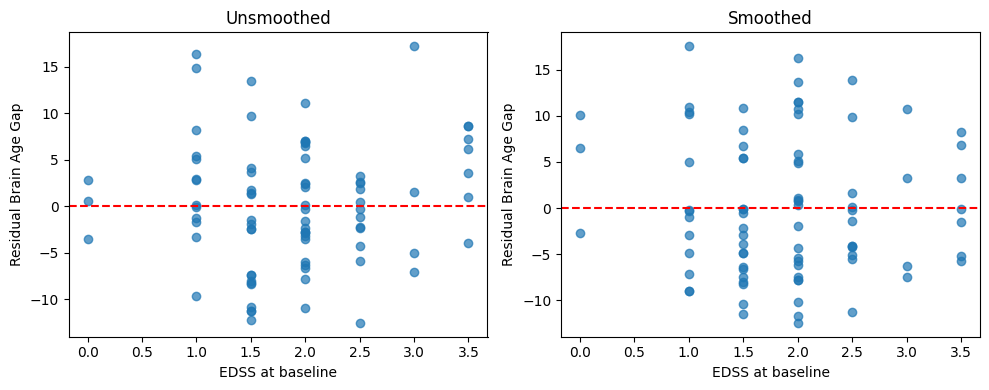

Unsmoothed n = 83
Smoothed n = 83


In [9]:
# Plot EDSS at baseline against residual BAG for both model variants
plot_bag_vs_clinical_two_models(df_unsmooth,df_smooth,x_col="EDSS_BL",bag_col="BAG_residual",x_label="EDSS at baseline",y_label="Residual Brain Age Gap"
)


Observation: No obvious relationship between residual BAG and EDSS at baseline.

### Plot: EDSS vs adjusted BAG

Adjusted BAG is a covariate-adjusted measure of BAG. In this analysis, it is used to examine whether EDSS is associated with BAG after adjustment for relevant covariates such as age, sex, disease duration, and symptom duration.

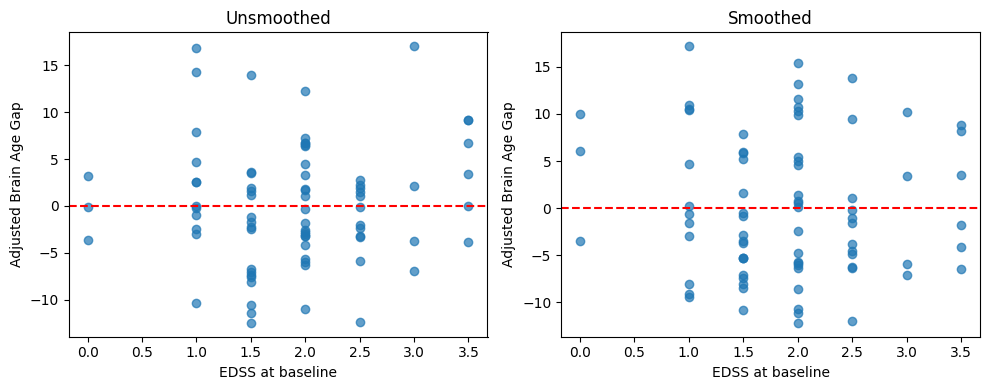

Unsmoothed n = 78
Smoothed n = 78


In [10]:
# Plot EDSS at baseline against adjusted BAG for both model variants
plot_bag_vs_clinical_two_models(df_unsmooth,df_smooth,x_col="EDSS_BL",bag_col="BAG_adj",x_label="EDSS at baseline",y_label="Adjusted Brain Age Gap"
)


Observation: No obvious relationship between adjusted BAG and EDSS at baseline.

### Correlation: EDSS and residual BAG

The relationship is quantified using Pearson correlation.

In [11]:
def pearson_ci(r, n):

    # Calculate a 95% confidence interval for a Pearson correlation coefficient
    # using Fisher's z-transformation

    # Convert the correlation coefficient to Fisher's z scale
    z = np.arctanh(r)

    # Standard error on the z scale
    se = 1 / np.sqrt(n - 3)

    # Critical value for an approximate 95% confidence interval
    z_crit = 1.96

    # Lower and upper limits on the z scale
    lo = z - z_crit * se
    hi = z + z_crit * se

    # Transform the confidence interval limits back to the correlation scale
    return np.tanh(lo), np.tanh(hi)




def compute_edss_correlations(df, raw_col, label):
    # Compute and print the Pearson correlation between EDSS at baseline and a selected BAG measure
    
    print(f"\n===== {label} =====")
    
    # Select only subjects with both EDSS and BAG values available
    mask_raw = df["EDSS_BL"].notna() & df[raw_col].notna()

    # Compute Pearson correlation and corresponding p-value
    r_raw, p_raw = pearsonr(
        df.loc[mask_raw, "EDSS_BL"],
        df.loc[mask_raw, raw_col]
    )

    # Calculate sample size and confidence interval
    n = mask_raw.sum()
    ci_lo, ci_hi = pearson_ci(r_raw, n)

    # Print results
    print(
        f"r = {r_raw:.3f}, "
        f"95% CI [{ci_lo:.3f}, {ci_hi:.3f}], "
        f"p = {p_raw:.3e}, "
        f"n = {n}\n"
    )

In [12]:
# Compute correlations between EDSS and residual BAG for both model variants
print("EDSS vs Residual BAG:")

compute_edss_correlations(df_unsmooth,raw_col="BAG_residual",label="Unsmoothed")

compute_edss_correlations(df_smooth,raw_col="BAG_residual",label="Smoothed")

EDSS vs Residual BAG:

===== Unsmoothed =====
r = 0.078, 95% CI [-0.140, 0.289], p = 4.838e-01, n = 83


===== Smoothed =====
r = -0.048, 95% CI [-0.261, 0.169], p = 6.653e-01, n = 83



Observation:

The unsmoothed model showed a weak positive relationship between residual BAG and EDSS, whereas the smoothed model showed a weak negative relationship. In both cases, the p-values were clearly above 0.05, indicating no statistically significant association between residual BAG and EDSS at baseline.

### Correlation: EDSS and adjusted BAG

The same correlation analysis is repeated using adjusted BAG.

In [13]:
# Compute correlations between EDSS and adjusted BAG for both model variants
print("\nEDSS vs Adjusted BAG:")

compute_edss_correlations(df_unsmooth,raw_col="BAG_adj",label="Unsmoothed")

compute_edss_correlations(df_smooth,raw_col="BAG_adj",label="Smoothed")


EDSS vs Adjusted BAG:

===== Unsmoothed =====
r = 0.080, 95% CI [-0.146, 0.297], p = 4.886e-01, n = 78


===== Smoothed =====
r = -0.047, 95% CI [-0.267, 0.178], p = 6.844e-01, n = 78



Observation: No significant relationship.

### Plot: EDSS groups vs residual BAG

Instead of treating EDSS as a continuous variable, this section compares BAG between two EDSS-based disability groups.


EDSS provides an overall disability score ranging from 0 (normal neurological examination) to 10 (death due to MS). Here, EDSS is divided into two groups:

- mild disability: EDSS < 3
- more severe disability: EDSS >= 3

At baseline, all MS subjects had an EDSS score of 5 or lower.

In [14]:
# Count the number of MS patients in each EDSS group
counts = df_unsmooth["edss_group"].value_counts()

print("Number of MS patients in each EDSS group:")
print(f"Mild: {counts.get('mild', 0)}")
print(f"Severe: {counts.get('severe', 0)}")

Number of MS patients in each EDSS group:
Mild: 72
Severe: 11


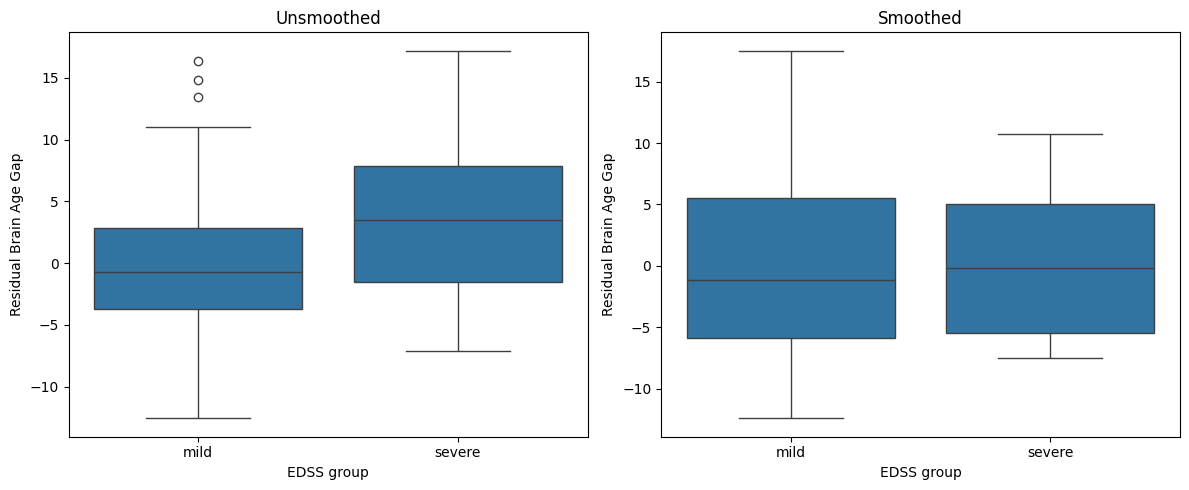

In [15]:
# Create boxplots comparing residual BAG between EDSS groups for the unsmoothed and smoothed models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Unsmoothed
sns.boxplot(
    x="edss_group",
    y="BAG_residual",
    data=df_unsmooth,
    ax=axes[0]
)

axes[0].set_title("Unsmoothed")
axes[0].set_xlabel("EDSS group")
axes[0].set_ylabel("Residual Brain Age Gap")

# Smoothed
sns.boxplot(
    x="edss_group",
    y="BAG_residual",
    data=df_smooth,
    ax=axes[1]
)

axes[1].set_title("Smoothed")
axes[1].set_xlabel("EDSS group")
axes[1].set_ylabel("Residual Brain Age Gap")

plt.tight_layout()
# plt.savefig("MS_baseline_res_BAG_EDSSgroup.png", dpi=300, bbox_inches="tight")
plt.show()

Observation:

For the unsmoothed model, there is a small difference between the mild and severe EDSS groups, with the severe group showing somewhat larger residual BAG values. For the smoothed model, there is no clear difference between the two EDSS groups.

### Correlation: EDSS groups and residual BAG

This section tests whether residual BAG differs between the mild and severe EDSS groups.

In [16]:
print("EDSS group vs Residual BAG:\n")

#Unsmoothed

# Extract residual BAG values for each EDSS group
mild_uns_raw = df_unsmooth[df_unsmooth["edss_group"] == "mild"]["BAG_residual"]
severe_uns_raw = df_unsmooth[df_unsmooth["edss_group"] == "severe"]["BAG_residual"]

# Independent samples t-test:
# compares group means and assumes approximately normally distributed data
t_uns_raw, p_t_uns_raw = ttest_ind(mild_uns_raw.dropna(), severe_uns_raw.dropna())

# Mann-Whitney U test:
# non-parametric alternative that compares group distributions/ranks
u_uns_raw, p_u_uns_raw = mannwhitneyu(mild_uns_raw.dropna(), severe_uns_raw.dropna())

# Smoothed
# Extract residual BAG values for each EDSS group
mild_sm_raw = df_smooth[df_smooth["edss_group"] == "mild"]["BAG_residual"]
severe_sm_raw = df_smooth[df_smooth["edss_group"] == "severe"]["BAG_residual"]

# Repeat the same tests for the smoothed model
t_sm_raw, p_t_sm_raw = ttest_ind(mild_sm_raw.dropna(), severe_sm_raw.dropna())
u_sm_raw, p_u_sm_raw = mannwhitneyu(mild_sm_raw.dropna(), severe_sm_raw.dropna())

# Print results
print("Unsmoothed:")
print(f"t = {t_uns_raw:.3f}, p = {p_t_uns_raw:.3e}")
print(f"U = {u_uns_raw:.3f}, p = {p_u_uns_raw:.3e}\n")

print("Smoothed:")
print(f"t = {t_sm_raw:.3f}, p = {p_t_sm_raw:.3e}")
print(f"U = {u_sm_raw:.3f}, p = {p_u_sm_raw:.3e}\n")

EDSS group vs Residual BAG:

Unsmoothed:
t = -1.860, p = 6.650e-02
U = 267.000, p = 8.438e-02

Smoothed:
t = -0.252, p = 8.015e-01
U = 371.000, p = 7.421e-01



Observation:

For the unsmoothed model, the severe EDSS group appears to have somewhat larger residual BAG values than the mild group. However, the difference is not statistically significant using either the independent samples t-test or the Mann-Whitney U test. The p-values are relatively close to 0.05, suggesting a possible trend, but this should be interpreted cautiously.

For the smoothed model, there is no significant difference in residual BAG between the EDSS groups.

The group sizes are unbalanced (11 subjects in the severe group and 72 subjects in the mild group), with substantially fewer subjects in the severe group than in the mild group. This may affect statistical power and should be considered when interpreting the results.

## Fatigue analysis

This section investigates whether fatigue at baseline is associated with residual BAG or adjusted BAG.

In [17]:
# Only fatigue info for baseline
df_fatigue_baseline = df_fatigue[df_fatigue["session"] == 0][["participant_id", "fatigue"]]

# Merge fatigue (baseline) to unsmoothed dataframe
df_unsmooth = df_unsmooth.merge(
    df_fatigue_baseline,
    on="participant_id",
    how="left")

# Merge fatigue (baseline) to smoothed dataframe
df_smooth = df_smooth.merge(
    df_fatigue_baseline,
    on="participant_id",
    how="left")

In [18]:
df_unsmooth.head()

,image_path,participant_id,sex,age_BL,EDSS_BL,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group,BAG_residual,disease_duration,symptom_duration,BAG_adj,fatigue
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,101,F,35.0,1.5,33.492504,-1.507496,33.919716,-1.080284,mild,-12.284878,0,2,-12.475490,6.888889
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,103,M,24.0,2.5,40.867573,16.867573,41.207672,17.207672,mild,-2.254982,1,2,-3.350060,2.000000
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,104,F,48.0,1.5,40.905470,-7.094528,41.245125,-6.754875,mild,-8.009435,0,18,-7.335937,2.111111
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1101,F,46.0,2.0,44.873960,-1.126041,45.166737,-0.833263,mild,-3.558252,1,1,-3.201111,6.888889
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1102,F,39.0,1.5,48.496895,9.496895,48.746880,9.746880,mild,1.754120,2,2,1.946152,6.222222


In [19]:
df_smooth.head()

,image_path,participant_id,sex,age_BL,EDSS_BL,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group,BAG_residual,disease_duration,symptom_duration,BAG_adj,fatigue
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,101,F,35.0,1.5,32.195694,-2.804306,32.905727,-2.094273,mild,-7.430194,0,2,-8.046251,6.888889
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,103,M,24.0,2.5,36.474022,12.474022,37.120200,13.120201,mild,-1.413909,1,2,-1.526618,2.000000
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,104,F,48.0,1.5,35.260303,-12.739697,35.924600,-12.075401,mild,-6.419534,0,18,-5.266438,2.111111
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1101,F,46.0,2.0,36.009117,-9.990883,36.662235,-9.337765,mild,-5.354728,1,1,-6.315050,6.888889
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1102,F,39.0,1.5,46.991196,7.991196,47.480396,8.480396,mild,6.733323,2,2,5.987143,6.222222


### Plot: Fatigue vs residual BAG

This plot shows whether patients with higher fatigue scores tend to have higher residual BAG values.

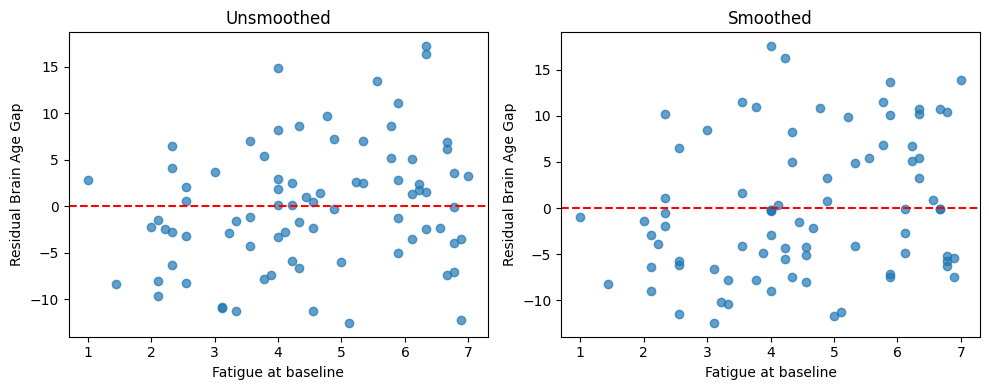

Unsmoothed n = 80
Smoothed n = 80


In [20]:
# Plot baseline fatigue against residual BAG for both model variants
plot_bag_vs_clinical_two_models(df_unsmooth,df_smooth,x_col="fatigue",bag_col="BAG_residual",x_label="Fatigue at baseline",y_label="Residual Brain Age Gap"
)


Observation:

At first glance, the data points appear relatively scattered. However, there are slightly more high residual BAG values among subjects with higher fatigue scores, suggesting a possible weak positive trend.

## Plot: Fatigue vs adjusted BAG

This plot evaluates whether the relationship between fatigue and BAG remains visible after covariate adjustment.

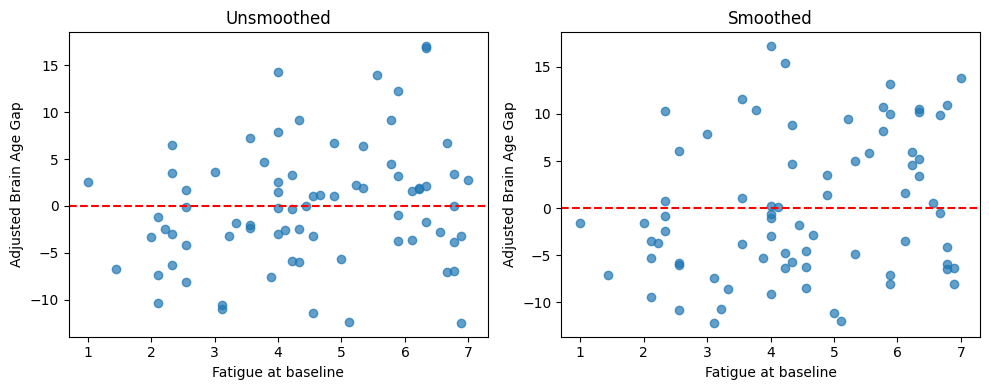

Unsmoothed n = 75
Smoothed n = 75


In [21]:
# Plot baseline fatigue against adjusted BAG for both model variants
plot_bag_vs_clinical_two_models(df_unsmooth,df_smooth,x_col="fatigue",bag_col="BAG_adj",x_label="Fatigue at baseline",y_label="Adjusted Brain Age Gap"
)



Observation: No clear trend.

### Correlation: Fatigue and residual BAG

Both Pearson and Spearman correlations are used.

Pearson correlation tests for a linear relationship, while Spearman correlation is rank-based and is less sensitive to non-normal distributions and outliers.

In [22]:
def compute_correlations(df, bag_column, label):
    # Compute Pearson and Spearman correlations between fatigue
    # and a selected BAG measure.

    # Remove subjects with missing fatigue or BAG values
    mask = df["fatigue"].notna() & df[bag_column].notna()
    
    x = df["fatigue"][mask]
    y = df[bag_column][mask]
    
    # Pearson
    r, p = pearsonr(x, y)
    n = len(x)
    ci_lo, ci_hi = pearson_ci(r, n)
    
    # Spearman
    r_s, p_s = spearmanr(x, y)
    
    print(f"\n{label}:")
    print(f"Pearson:  r = {r:.3f}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}], p = {p:.3e}")
    print(f"Spearman: r_s = {r_s:.3f}, p = {p_s:.3e}")


# Correlation between fatigue and residual BAG for the unsmoothed model
print("Residual BAG and fatigue:")
compute_correlations(df_unsmooth, "BAG_residual", "Unsmoothed")

# Correlation between fatigue and residual BAG for the smoothed model
compute_correlations(df_smooth, "BAG_residual", "Smoothed")

Residual BAG and fatigue:

Unsmoothed:
Pearson:  r = 0.242, 95% CI [0.024, 0.438], p = 3.050e-02
Spearman: r_s = 0.217, p = 5.271e-02

Smoothed:
Pearson:  r = 0.261, 95% CI [0.044, 0.455], p = 1.923e-02
Spearman: r_s = 0.260, p = 1.977e-02


Observation:

Residual BAG showed a weak positive association with fatigue. The association reached statistical significance using Pearson correlation in both models. Spearman correlation reached significance for the smoothed model and was close to significance for the unsmoothed model.

Because the effect is weak and the p-values are close to the significance threshold, this result should be interpreted cautiously.

### Correlation: Fatigue and adjusted BAG

The fatigue analysis is repeated using adjusted BAG.

In [23]:
# Correlation between fatigue and adjusted BAG for the unsmoothed model
print("Adjusted BAG and fatigue:")
compute_correlations(df_unsmooth, "BAG_adj", "Unsmoothed")

# Correlation between fatigue and adjusted BAG for the smoothed model
compute_correlations(df_smooth, "BAG_adj", "Smoothed")

Adjusted BAG and fatigue:

Unsmoothed:
Pearson:  r = 0.218, 95% CI [-0.009, 0.424], p = 5.966e-02
Spearman: r_s = 0.183, p = 1.164e-01

Smoothed:
Pearson:  r = 0.262, 95% CI [0.037, 0.461], p = 2.323e-02
Spearman: r_s = 0.229, p = 4.808e-02


Observation:

A positive association between fatigue and adjusted BAG was observed in the smoothed model, reaching statistical significance for both Pearson and Spearman correlations. In contrast, the unsmoothed model showed only a weak, non-significant trend.

This suggests that fatigue may be weakly related to adjusted BAG, particularly in the smoothed model, but the result should be interpreted with caution.

## Disease and symptom duration-analysis

This section investigates whether residual BAG is associated with disease duration or symptom duration at baseline.

### Plot: Disease/symptom duration vs residual BAG

Disease duration and symptom duration are plotted against residual BAG to visually assess whether longer disease history is associated with higher brain age gap.

In [24]:
def plot_duration_all(df, model_name):


    # Plot disease duration and symptom duration against residual BAG for one model variant

    # Create two plots: one for disease duration and one for symptom duration
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Keep only subjects with non-missing values for each duration variable and residual BAG
    mask_dis = df["disease_duration"].notna() & df["BAG_residual"].notna()
    mask_sym = df["symptom_duration"].notna() & df["BAG_residual"].notna()
    
    # Disease duration
    axes[0].scatter(
        df.loc[mask_dis, "disease_duration"],
        df.loc[mask_dis, "BAG_residual"]
    )

    # Horizontal reference line at BAG = 0
    axes[0].axhline(0, linestyle="--")
    axes[0].set_title(f"{model_name} – Disease duration")
    axes[0].set_xlabel("Disease duration")
    axes[0].set_ylabel("Residual BAG")
    
    # Symptom duration
    axes[1].scatter(
        df.loc[mask_sym, "symptom_duration"],
        df.loc[mask_sym, "BAG_residual"]
    )
    axes[1].axhline(0, linestyle="--")
    axes[1].set_title(f"{model_name} – Symptom duration")
    axes[1].set_xlabel("Symptom duration")
    axes[1].set_ylabel("Residual BAG")
    
    plt.tight_layout()
    plt.show()

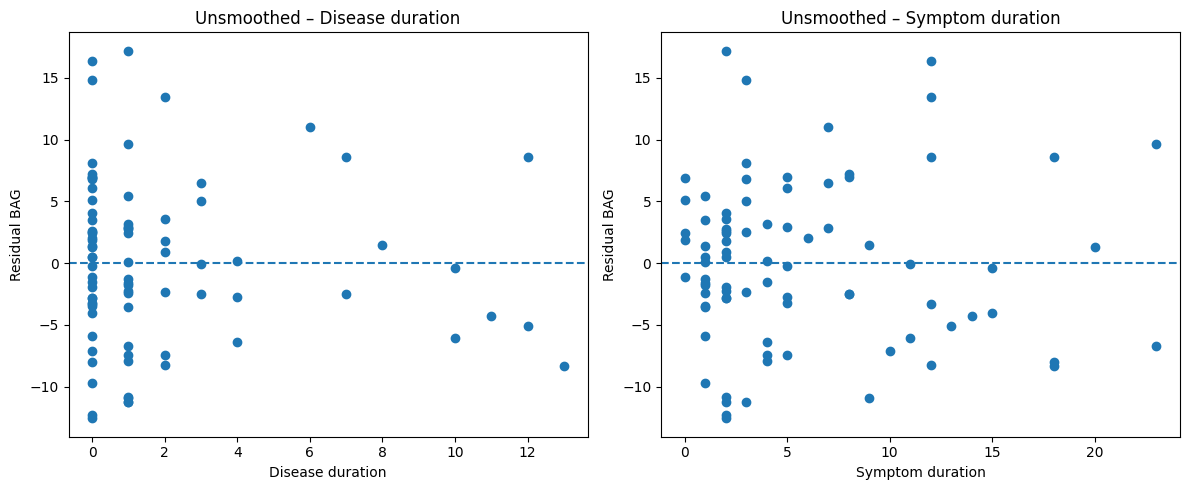

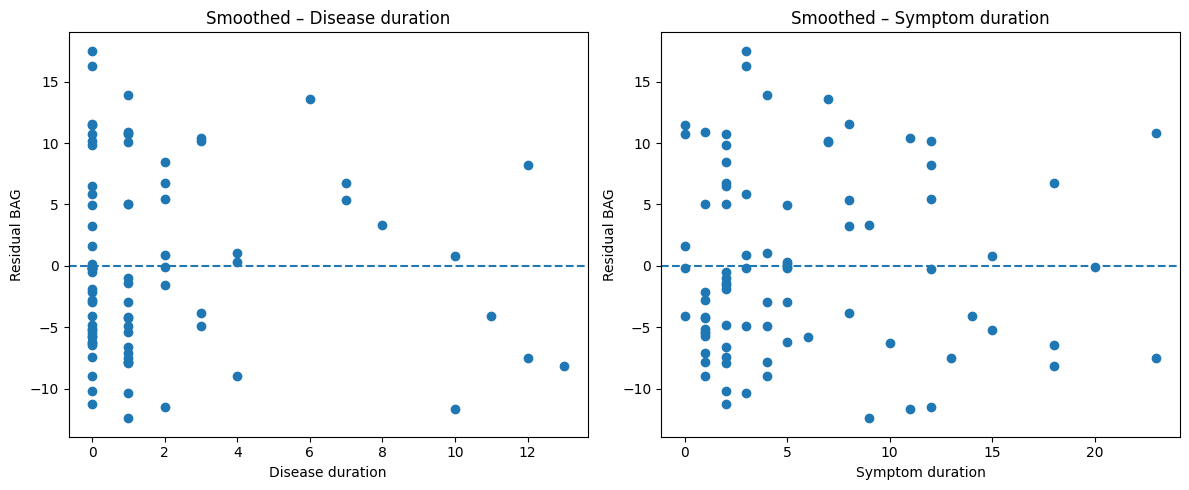

In [25]:
# Plot disease duration and symptom duration against residual BAG for both the unsmoothed and smoothed models
plot_duration_all(df_unsmooth, "Unsmoothed")
plot_duration_all(df_smooth, "Smoothed")

Observation: No clear trends.

### Correlation: Disease/symptom duration and residual BAG

The visual inspection is followed by Pearson correlation analyses.

In [26]:
print("Residual BAG vs duration:")

def compute_duration_correlations(df, duration_col, bag_col, label):
    # Compute Pearson correlation between a duration variable and a selected BAG measure

    # Keep only complete cases for the selected variables
    mask = df[duration_col].notna() & df[bag_col].notna()
    
    x = df[duration_col][mask]
    y = df[bag_col][mask]
    
    # Pearson correlation between duration and BAG
    r, p = pearsonr(x, y)
    
    print(f"\n{label}:")
    print(f"Pearson: r = {r:.3f}, p = {p:.3e}")


# Unsmoothed
compute_duration_correlations(df_unsmooth, "disease_duration", "BAG_residual",
                              "Unsmoothed – Disease duration")

compute_duration_correlations(df_unsmooth, "symptom_duration", "BAG_residual",
                              "Unsmoothed – Symptom duration")

# Smoothed
compute_duration_correlations(df_smooth, "disease_duration", "BAG_residual",
                              "Smoothed – Disease duration")


compute_duration_correlations(df_smooth, "symptom_duration", "BAG_residual",
                              "Smoothed – Symptom duration")


Residual BAG vs duration:

Unsmoothed – Disease duration:
Pearson: r = -0.056, p = 6.151e-01

Unsmoothed – Symptom duration:
Pearson: r = 0.010, p = 9.253e-01

Smoothed – Disease duration:
Pearson: r = -0.032, p = 7.768e-01

Smoothed – Symptom duration:
Pearson: r = -0.003, p = 9.803e-01


Observation: No significant associations were observed for any model variant.